# Module 3 - Machine Learning: House Resale Price Prediction Model

Expected files in `../data/`:
- `train.csv`: labeled training data that includes the target column `resale_price`
- `test.csv`: unlabeled scoring data that includes the identifier column `Id`

Generated file:
- `../output/Team_10_submission.csv`

the following approaches are considered for 


In [ ]:
# Load required libraries

from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

pd.set_option("display.max_columns", 200)

def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd / "m3-project", cwd.parent]

    for candidate in candidates:
        if (candidate / "data").exists() and (candidate / "workflow").exists():
            return candidate

    raise FileNotFoundError(
        "Could not locate the m3-project root. Run the notebook from the project workspace."
    )


PROJECT_ROOT = resolve_project_root()
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "output"

TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"
OUTPUT_PATH = OUTPUT_DIR / "Team_10_submission.csv"

# check if required files exist
if not TRAIN_PATH.exists():
    raise FileNotFoundError(f"Training data not found at {TRAIN_PATH}")
if not TEST_PATH.exists():
    raise FileNotFoundError(f"Test data not found at {TEST_PATH}")

# per csv file column names, set target and id candidates
TARGET_COLUMN = "resale_price"
ID_CANDIDATES = ["Id", "id"]

# print all variables
print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")
print(f"TRAIN_PATH: {TRAIN_PATH}")
print(f"TEST_PATH: {TEST_PATH}")
print(f"OUTPUT_PATH: {OUTPUT_PATH}")
print(f"TARGET_COLUMN: {TARGET_COLUMN}")
print(f"ID_CANDIDATES: {ID_CANDIDATES}")

PROJECT_ROOT: /home/franklin/dsai/dsai-5m-projects/m3-project
DATA_DIR: /home/franklin/dsai/dsai-5m-projects/m3-project/data
OUTPUT_DIR: /home/franklin/dsai/dsai-5m-projects/m3-project/output
TRAIN_PATH: /home/franklin/dsai/dsai-5m-projects/m3-project/data/train.csv
TEST_PATH: /home/franklin/dsai/dsai-5m-projects/m3-project/data/test.csv
OUTPUT_PATH: /home/franklin/dsai/dsai-5m-projects/m3-project/output/Team_10_submission.csv
TARGET_COLUMN: resale_price
ID_CANDIDATES: ['Id', 'id']


In [5]:
# now, load the data to a pandas dataframe

def load_required_csv(path: Path, label: str) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(
            f"{label} file not found at {path}. Add the expected CSV before running the notebook."
        )

    try:
        df = pd.read_csv(path, low_memory=False)
    except pd.errors.EmptyDataError as exc:
        raise ValueError(
            f"{label} file at {path} is empty. Add real data before training the model."
        ) from exc

    if df.empty:
        raise ValueError(f"{label} file at {path} has no rows.")

    return df


train_df = load_required_csv(TRAIN_PATH, "Training")
test_df = load_required_csv(TEST_PATH, "Test")



In [ ]:
# get ID column and Target column, check if they exist

ID_COLUMN = next((column for column in ID_CANDIDATES if column in test_df.columns), None)

if TARGET_COLUMN not in train_df.columns:
    raise KeyError(
        f"Training data must include the target column '{TARGET_COLUMN}'. "
        f"Available columns: {list(train_df.columns)}"
    )

if ID_COLUMN is None:
    raise KeyError(
        "Test data must include one of the identifier columns "
        f"{ID_CANDIDATES}. "
        f"Available columns: {list(test_df.columns)}"
    )

# show first 5 rows
display(train_df.head())
display(test_df.head())

# show shapes
print(f"train shape: {train_df.shape}")
print(f"test shape: {test_df.shape}")


,id,Tranc_YearMonth,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,Tranc_Year,Tranc_Month,mid_storey,lower,upper,mid,full_flat_type,address,floor_area_sqft,hdb_age,max_floor_lvl,year_completed,residential,commercial,market_hawker,multistorey_carpark,precinct_pavilion,total_dwelling_units,1room_sold,2room_sold,3room_sold,4room_sold,5room_sold,exec_sold,multigen_sold,studio_apartment_sold,1room_rental,2room_rental,3room_rental,other_room_rental,postal,Latitude,Longitude,planning_area,Mall_Nearest_Distance,Mall_Within_500m,Mall_Within_1km,Mall_Within_2km,Hawker_Nearest_Distance,Hawker_Within_500m,Hawker_Within_1km,Hawker_Within_2km,hawker_food_stalls,hawker_market_stalls,mrt_nearest_distance,mrt_name,bus_interchange,mrt_interchange,mrt_latitude,mrt_longitude,bus_stop_nearest_distance,bus_stop_name,bus_stop_latitude,bus_stop_longitude,pri_sch_nearest_distance,pri_sch_name,vacancy,pri_sch_affiliation,pri_sch_latitude,pri_sch_longitude,sec_sch_nearest_dist,sec_sch_name,cutoff_point,affiliation,sec_sch_latitude,sec_sch_longitude
0,88471,2016-05,KALLANG/WHAMPOA,4 ROOM,3B,UPP BOON KENG RD,10 TO 12,90.0,Model A,2006,680000.0,2016,5,11,10,12,11,4 ROOM Model A,"3B, UPP BOON KENG RD",968.760,15,25,2005,Y,N,N,N,N,142,0,0,0,96,46,0,0,0,0,0,0,0,382003,1.314299,103.872828,Kallang,1094.090418,NaN,NaN,7.0,154.753357,1.0,3.0,13.0,84,60,330.083069,Kallang,0,0,1.311540,103.871731,29.427395,Blk 3B,1.314433,103.872600,1138.633422,Geylang Methodist School,78,1,1.317659,103.882504,1138.633422,Geylang Methodist School,224,0,1.317659,103.882504
1,122598,2012-07,BISHAN,5 ROOM,153,BISHAN ST 13,07 TO 09,130.0,Improved,1987,665000.0,2012,7,8,7,9,8,5 ROOM Improved,"153, BISHAN ST 13",1399.320,34,9,1987,Y,N,N,N,N,112,0,0,0,56,56,0,0,0,0,0,0,0,570153,1.346086,103.855078,Bishan,866.941448,NaN,1.0,3.0,640.151925,NaN,1.0,7.0,80,77,903.659703,Bishan,1,1,1.350580,103.848305,58.207761,BLK 151A MKT,1.345659,103.855381,415.607357,Kuo Chuan Presbyterian Primary School,45,1,1.349783,103.854529,447.894399,Kuo Chuan Presbyterian Secondary School,232,0,1.350110,103.854892
2,170897,2013-07,BUKIT BATOK,EXECUTIVE,289B,BT BATOK ST 25,13 TO 15,144.0,Apartment,1997,838000.0,2013,7,14,13,15,14,EXECUTIVE Apartment,"289B, BT BATOK ST 25",1550.016,24,16,1996,Y,N,N,N,N,90,0,0,0,0,30,60,0,0,0,0,0,0,651289,1.343867,103.760535,Bukit Batok,1459.579948,NaN,NaN,4.0,1762.082341,NaN,NaN,1.0,84,95,1334.251197,Bukit Batok,1,0,1.349561,103.749970,214.747860,Blk 289E,1.344064,103.758613,498.849039,Keming Primary School,39,0,1.345245,103.756265,180.074558,Yusof Ishak Secondary School,188,0,1.342334,103.760013
3,86070,2012-04,BISHAN,4 ROOM,232,BISHAN ST 22,01 TO 05,103.0,Model A,1992,550000.0,2012,4,3,1,5,3,4 ROOM Model A,"232, BISHAN ST 22",1108.692,29,11,1990,Y,Y,N,N,N,75,0,0,0,68,7,0,0,0,0,0,0,0,570232,1.358245,103.845504,Bishan,950.175199,NaN,1.0,4.0,726.215262,NaN,1.0,9.0,32,86,907.453484,Bishan,1,1,1.350580,103.848305,43.396521,Opp Bishan Nth Shop Mall,1.358045,103.845169,389.515528,Catholic High School,20,1,1.354789,103.844934,389.515528,Catholic High School,253,1,1.354789,103.844934
4,153632,2017-12,YISHUN,4 ROOM,876,YISHUN ST 81,01 TO 03,83.0,Simplified,1987,298000.0,2017,12,2,1,3,2,4 ROOM Simplified,"876, YISHUN ST 81",893.412,34,4,1987,Y,N,N,N,N,48,0,0,0,30,18,0,0,0,0,0,0,0,760876,1.414745,103.835532,Yishun,729.771895,NaN,1.0,2.0,1540.151439,NaN,NaN,1.0,45,0,412.343032,Khatib,0,0,1.417131,103.832692,129.422752,Blk 873,1.415424,103.836477,401.200584,Naval Base Primary School,74,0,1.416280,103.838798,312.025435,Orchid Park Secondary School,208,0,1.414888,103.838335


,id,Tranc_YearMonth,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,Tranc_Year,Tranc_Month,mid_storey,lower,upper,mid,full_flat_type,address,floor_area_sqft,hdb_age,max_floor_lvl,year_completed,residential,commercial,market_hawker,multistorey_carpark,precinct_pavilion,total_dwelling_units,1room_sold,2room_sold,3room_sold,4room_sold,5room_sold,exec_sold,multigen_sold,studio_apartment_sold,1room_rental,2room_rental,3room_rental,other_room_rental,postal,Latitude,Longitude,planning_area,Mall_Nearest_Distance,Mall_Within_500m,Mall_Within_1km,Mall_Within_2km,Hawker_Nearest_Distance,Hawker_Within_500m,Hawker_Within_1km,Hawker_Within_2km,hawker_food_stalls,hawker_market_stalls,mrt_nearest_distance,mrt_name,bus_interchange,mrt_interchange,mrt_latitude,mrt_longitude,bus_stop_nearest_distance,bus_stop_name,bus_stop_latitude,bus_stop_longitude,pri_sch_nearest_distance,pri_sch_name,vacancy,pri_sch_affiliation,pri_sch_latitude,pri_sch_longitude,sec_sch_nearest_dist,sec_sch_name,cutoff_point,affiliation,sec_sch_latitude,sec_sch_longitude
0,114982,2012-11,YISHUN,4 ROOM,173,YISHUN AVE 7,07 TO 09,84.0,Simplified,1987,2012,11,8,7,9,8,4 ROOM Simplified,"173, YISHUN AVE 7",904.176,34,12,1986,Y,Y,N,N,N,132,0,0,0,92,40,0,0,0,0,0,0,0,760173,1.437066,103.831121,Yishun,877.431572,NaN,2.0,4.0,687.576779,NaN,1.0,1.0,56,123,686.660434,Canberra,0,0,1.443077,103.829703,75.683952,Blk 174,1.437558,103.831591,426.467910,Ahmad Ibrahim Primary School,92,0,1.433681,103.832924,156.322353,Ahmad Ibrahim Secondary School,218,0,1.436235,103.829987
1,95653,2019-08,JURONG WEST,5 ROOM,986C,JURONG WEST ST 93,04 TO 06,112.0,Premium Apartment,2008,2019,8,5,4,6,5,5 ROOM Premium Apartment,"986C, JURONG WEST ST 93",1205.568,13,14,2002,Y,N,N,N,N,53,0,0,0,28,25,0,0,0,0,0,0,0,643986,1.336957,103.695668,Jurong West,534.037705,NaN,1.0,3.0,2122.346226,NaN,NaN,NaN,72,94,169.478175,Pioneer,0,0,1.337343,103.697143,88.993058,Blk 653B,1.336491,103.696319,439.756851,Jurong West Primary School,45,0,1.339244,103.698896,739.371688,Jurong West Secondary School,199,0,1.335256,103.702098
2,40303,2013-10,ANG MO KIO,3 ROOM,534,ANG MO KIO AVE 10,07 TO 09,68.0,New Generation,1980,2013,10,8,7,9,8,3 ROOM New Generation,"534, ANG MO KIO AVE 10",731.952,41,12,1979,Y,N,N,N,N,218,0,0,191,22,1,1,0,0,0,0,3,0,560534,1.374058,103.854168,Ang Mo Kio,817.050453,NaN,2.0,3.0,152.287621,1.0,3.0,11.0,50,100,694.220448,Ang Mo Kio,1,0,1.369465,103.849939,86.303575,Blk 532,1.374255,103.854919,355.882207,Jing Shan Primary School,36,0,1.371893,103.851811,305.071191,Anderson Secondary School,245,0,1.374242,103.851430
3,109506,2017-10,WOODLANDS,4 ROOM,29,MARSILING DR,01 TO 03,97.0,New Generation,1979,2017,10,2,1,3,2,4 ROOM New Generation,"29, MARSILING DR",1044.108,42,14,1976,Y,N,N,N,N,104,0,0,0,104,0,0,0,0,0,0,0,0,731029,1.442748,103.772922,Woodlands,1272.737194,NaN,NaN,3.0,501.892158,NaN,1.0,2.0,52,112,1117.203587,Marsiling,0,0,1.432757,103.773982,108.459039,Blk 32,1.443650,103.773295,929.744711,Marsiling Primary School,54,0,1.434423,103.773698,433.454591,Woodlands Secondary School,188,0,1.439183,103.774499
4,100149,2016-08,BUKIT BATOK,4 ROOM,170,BT BATOK WEST AVE 8,16 TO 18,103.0,Model A,1985,2016,8,17,16,18,17,4 ROOM Model A,"170, BT BATOK WEST AVE 8",1108.692,36,25,1985,Y,N,N,N,N,144,0,0,0,48,96,0,0,0,0,0,0,0,650170,1.346556,103.740101,Bukit Batok,1070.963675,NaN,NaN,5.0,437.593564,1.0,2.0,2.0,60,87,987.976010,Chinese Garden,0,0,1.342441,103.732225,113.645431,Blk 169,1.346899,103.741064,309.926934,Princess Elizabeth Primary School,40,0,1.349195,103.741000,217.295361,Bukit Batok Secondary School,223,0,1.348351,103.740873


train shape: (150634, 77)
test shape: (16737, 76)


In [7]:
# set x and y
# Copy the training data frame, excluding the target column
# The target column, resale_price, is used for model evaluation later
X = train_df.drop(columns=[TARGET_COLUMN]).copy()
y = train_df[TARGET_COLUMN].copy()


# Print shapes of X and y
print("X shape:", X.shape)
print("y shape:", y.shape)

# Drop the ID column from the X dataset if it exists (it's unnecessary for training)
if ID_COLUMN in X.columns:
    X = X.drop(columns=[ID_COLUMN])


# Copy the test data frame
# The ID column (if it exists) will be saved separately
X_test = test_df.copy()
# Save the IDs from the test data frame
test_ids = X_test[ID_COLUMN]


# Check if the ID column exists in the test data frame
if ID_COLUMN in X_test.columns:
    # If it does, drop it from the test data frame
    X_test = X_test.drop(columns=[ID_COLUMN])

# Find the columns in the training data frame that are not present in the test data frame
missing_test_columns = sorted(set(X.columns) - set(X_test.columns))
# Find the columns in the test data frame that are not present in the training data frame
extra_test_columns = sorted(set(X_test.columns) - set(X.columns))


# If there are any columns in the test data frame that are not present in the training data frame,
# raise an error. This is because the model will not know how to handle these columns.
if missing_test_columns:
    raise ValueError(
        "Test data is missing training feature columns: " + ", ".join(missing_test_columns)
    )

# If there are any columns in the test data frame that are not present in the training data frame,
# drop them from the test data frame. This is because the model will not know how to handle these columns.
if extra_test_columns:
    print("Dropping test-only columns:", extra_test_columns)
    X_test = X_test.drop(columns=extra_test_columns)


# Make sure that the columns in the test data frame match the columns in the training data frame
# This is important because the model was trained using the columns in the training data frame
# If the columns in the test data frame do not match the columns in the training data frame,
# the model will not know how to handle the extra or missing columns in the test data frame.
X_test = X_test[X.columns]
# By aligning the columns in the test data frame with the columns in the training data frame,
# we ensure that the model can handle the test data correctly.


X shape: (150634, 76)
y shape: (150634,)


In [ ]:

# Extracting the numeric and categorical features from the dataset
# "select_dtypes" is a function from pandas that allows to select the columns based on the data type
# "include" and "exclude" parameters are used to specify the data types to include or exclude
# "include=[np.number]" means that we want to include columns with numeric data types
# "exclude=[np.number]" means that we want to exclude columns with numeric data types
# ".columns.tolist()" is used to convert the selected columns into a list
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()


# Iterate over each column in the categorical_features list
for column in categorical_features:
    # Convert the column in the X DataFrame to string data type
    X[column] = X[column].astype("string")
    # Convert the column in the X_test DataFrame to string data type
    X_test[column] = X_test[column].astype("string")

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
            ]),
            numeric_features,
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]),
            categorical_features,
        ),
    ],
    remainder="drop",
)

print(f"numeric features: {len(numeric_features)}")
print(f"categorical features: {len(categorical_features)}")


numeric features: 55
categorical features: 20


In [9]:

# Define two candidate models: Random Forest and Extra Trees
# Both models are regressors, meaning they predict continuous values.
# They share some common parameters like `n_estimators`, `max_depth`,
# `min_samples_leaf`, and `max_features`. These parameters control
# the complexity of the model and the number of features to consider.
candidate_models = {
    "random_forest": RandomForestRegressor(
        n_estimators=120,  # Number of trees in the forest.
        max_depth=30,  # Maximum depth of each tree.
        min_samples_leaf=2,  # Minimum number of samples required to be at a leaf node.
        max_features="sqrt",  # Maximum number of features to consider when looking for the best split.
        random_state=42,  # Seed for random number generation. Ensures reproducibility.
        n_jobs=-1,  # Use all available CPUs.
    ),
    "extra_trees": ExtraTreesRegressor(
        n_estimators=160,  # Number of trees in the forest.
        max_depth=30,  # Maximum depth of each tree.
        min_samples_leaf=2,  # Minimum number of samples required to be at a leaf node.
        max_features="sqrt",  # Maximum number of features to consider when looking for the best split.
        random_state=42,  # Seed for random number generation. Ensures reproducibility.
        n_jobs=-1,  # Use all available CPUs.
    ),
}

model_scores = []

# Loop through each candidate model
for model_name, estimator in candidate_models.items():
    # Create a pipeline that applies the preprocessor and the estimator
    pipeline = Pipeline([
        ("preprocessor", preprocessor),  # Apply the preprocessor to the data
        ("model", estimator),  # Apply the estimator to the preprocessed data
    ])
    # Evaluate the model using cross-validation
    # The `cross_val_score` function takes the pipeline, the input features and target variable,
    # the number of folds for cross-validation, the scoring metric, and the number of CPUs to use.
    # The negative root mean squared error is used as the scoring metric, which is the negative of the mean squared error.
    # The mean and standard deviation of the negative root mean squared error scores are stored in the `model_scores` list.
    rmse_scores = -cross_val_score(
        pipeline,
        X,
        y,
        cv=3,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
    )
    model_scores.append(
        {
            "model": model_name,  # Store the name of the model
            "cv_rmse_mean": rmse_scores.mean(),  # Store the mean of the negative root mean squared error scores
            "cv_rmse_std": rmse_scores.std(),  # Store the standard deviation of the negative root mean squared error scores
        }
    )

scores_df = pd.DataFrame(model_scores).sort_values("cv_rmse_mean")
display(scores_df)

best_model_name = scores_df.iloc[0]["model"]
best_estimator = candidate_models[best_model_name]
print(f"Selected model: {best_model_name}")


,model,cv_rmse_mean,cv_rmse_std
0,random_forest,58221.141223,510.173513
1,extra_trees,74705.678821,579.350821


Selected model: random_forest


In [10]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

validation_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_estimator),
])

validation_pipeline.fit(X_train, y_train)
valid_predictions = validation_pipeline.predict(X_valid)

rmse = mean_squared_error(y_valid, valid_predictions, squared=False)
mae = mean_absolute_error(y_valid, valid_predictions)

print(f"Validation RMSE: {rmse:,.2f}")
print(f"Validation MAE: {mae:,.2f}")


Validation RMSE: 58,812.73
Validation MAE: 45,178.79


In [11]:
final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_estimator),
])

final_pipeline.fit(X, y)
test_predictions = final_pipeline.predict(X_test)

submission_df = pd.DataFrame(
    {
        ID_COLUMN: test_ids,
        "Predicted": np.round(test_predictions, 2),
    }
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
submission_df.to_csv(OUTPUT_PATH, index=False)

display(submission_df.head())
print(f"Submission saved to: {OUTPUT_PATH}")


,id,Predicted
0,114982,359716.49
1,95653,467182.79
2,40303,344351.19
3,109506,333188.16
4,100149,454583.47


Submission saved to: /home/franklin/dsai/dsai-5m-projects/m3-project/output/Team_10_submission.csv


## Recommended Next Step

Run the notebook after adding the real `train.csv` file. If the target column name differs from `resale_price`, update `TARGET_COLUMN` in the configuration cell before training.

In [12]:
# Compare Actual vs Predicted Resale Prices on Validation Data

# Create a DataFrame with actual and predicted values for side-by-side comparison
comparison_df = pd.DataFrame({
    "Actual": y_valid.values,
    "Predicted": np.round(valid_predictions, 2),
    "Residual": y_valid.values - valid_predictions,
    "Residual_Pct": np.round(((y_valid.values - valid_predictions) / y_valid.values) * 100, 2),
    "Abs_Error": np.abs(y_valid.values - valid_predictions)
})

print("First 10 rows of Actual vs Predicted comparison:")
display(comparison_df.head(10))

# Summary statistics for residuals
print("\n--- Residual Summary Statistics ---")
print(f"Mean Residual: ${comparison_df['Residual'].mean():,.2f}")
print(f"Median Residual: ${comparison_df['Residual'].median():,.2f}")
print(f"Std Residual: ${comparison_df['Residual'].std():,.2f}")
print(f"Mean Absolute Error: ${comparison_df['Abs_Error'].mean():,.2f}")
print(f"Mean Absolute Percentage Error: {np.abs(comparison_df['Residual_Pct']).mean():.2f}%")

# Distribution of residuals
print("\n--- Residual Distribution ---")
display(comparison_df['Residual'].describe())

# Show predictions within certain error ranges
within_10k = (comparison_df['Abs_Error'] <= 10000).sum()
within_50k = (comparison_df['Abs_Error'] <= 50000).sum()
within_100k = (comparison_df['Abs_Error'] <= 100000).sum()

print(f"\n--- Prediction Accuracy ---")
print(f"Predictions within $10K of actual: {within_10k} ({within_10k/len(comparison_df)*100:.1f}%)")
print(f"Predictions within $50K of actual: {within_50k} ({within_50k/len(comparison_df)*100:.1f}%)")
print(f"Predictions within $100K of actual: {within_100k} ({within_100k/len(comparison_df)*100:.1f}%)")

# Sample of best and worst predictions
print("\n--- 5 Most Accurate Predictions (lowest absolute error) ---")
display(comparison_df.nsmallest(5, 'Abs_Error')[['Actual', 'Predicted', 'Residual', 'Abs_Error']])

print("\n--- 5 Least Accurate Predictions (highest absolute error) ---")
display(comparison_df.nlargest(5, 'Abs_Error')[['Actual', 'Predicted', 'Residual', 'Abs_Error']])

First 10 rows of Actual vs Predicted comparison:


,Actual,Predicted,Residual,Residual_Pct,Abs_Error
0,385000.0,438262.56,-53262.557059,-13.83,53262.557059
1,500000.0,487874.18,12125.821395,2.43,12125.821395
2,868000.0,726553.02,141446.981759,16.30,141446.981759
3,483000.0,396231.61,86768.387360,17.96,86768.387360
4,450000.0,508467.07,-58467.065323,-12.99,58467.065323
5,395000.0,414597.41,-19597.407770,-4.96,19597.407770
6,500000.0,477806.20,22193.797500,4.44,22193.797500
7,310000.0,381818.32,-71818.323729,-23.17,71818.323729
8,420000.0,450594.12,-30594.118910,-7.28,30594.118910
9,537000.0,499602.97,37397.027251,6.96,37397.027251



--- Residual Summary Statistics ---
Mean Residual: $-19.09
Median Residual: $-7,268.56
Std Residual: $58,813.70
Mean Absolute Error: $45,178.79
Mean Absolute Percentage Error: 10.75%

--- Residual Distribution ---


count     30127.000000
mean        -19.088874
std       58813.701538
min     -173898.605116
25%      -40855.669471
50%       -7268.562070
75%       31465.071580
max      373330.417088
Name: Residual, dtype: float64


--- Prediction Accuracy ---
Predictions within $10K of actual: 4512 (15.0%)
Predictions within $50K of actual: 19190 (63.7%)
Predictions within $100K of actual: 27848 (92.4%)

--- 5 Most Accurate Predictions (lowest absolute error) ---


,Actual,Predicted,Residual,Abs_Error
10430,503500.0,503502.87,-2.865703,2.865703
28795,380000.0,379996.83,3.172525,3.172525
28299,465888.0,465891.31,-3.308456,3.308456
14000,359000.0,359005.41,-5.405628,5.405628
8841,405000.0,405009.68,-9.679734,9.679734



--- 5 Least Accurate Predictions (highest absolute error) ---


,Actual,Predicted,Residual,Abs_Error
10741,900000.0,526669.58,373330.417088,373330.417088
1960,970000.0,598908.54,371091.456689,371091.456689
14196,1000000.0,644664.94,355335.063764,355335.063764
8391,888000.0,533134.69,354865.311905,354865.311905
3502,1138888.0,802938.18,335949.820352,335949.820352


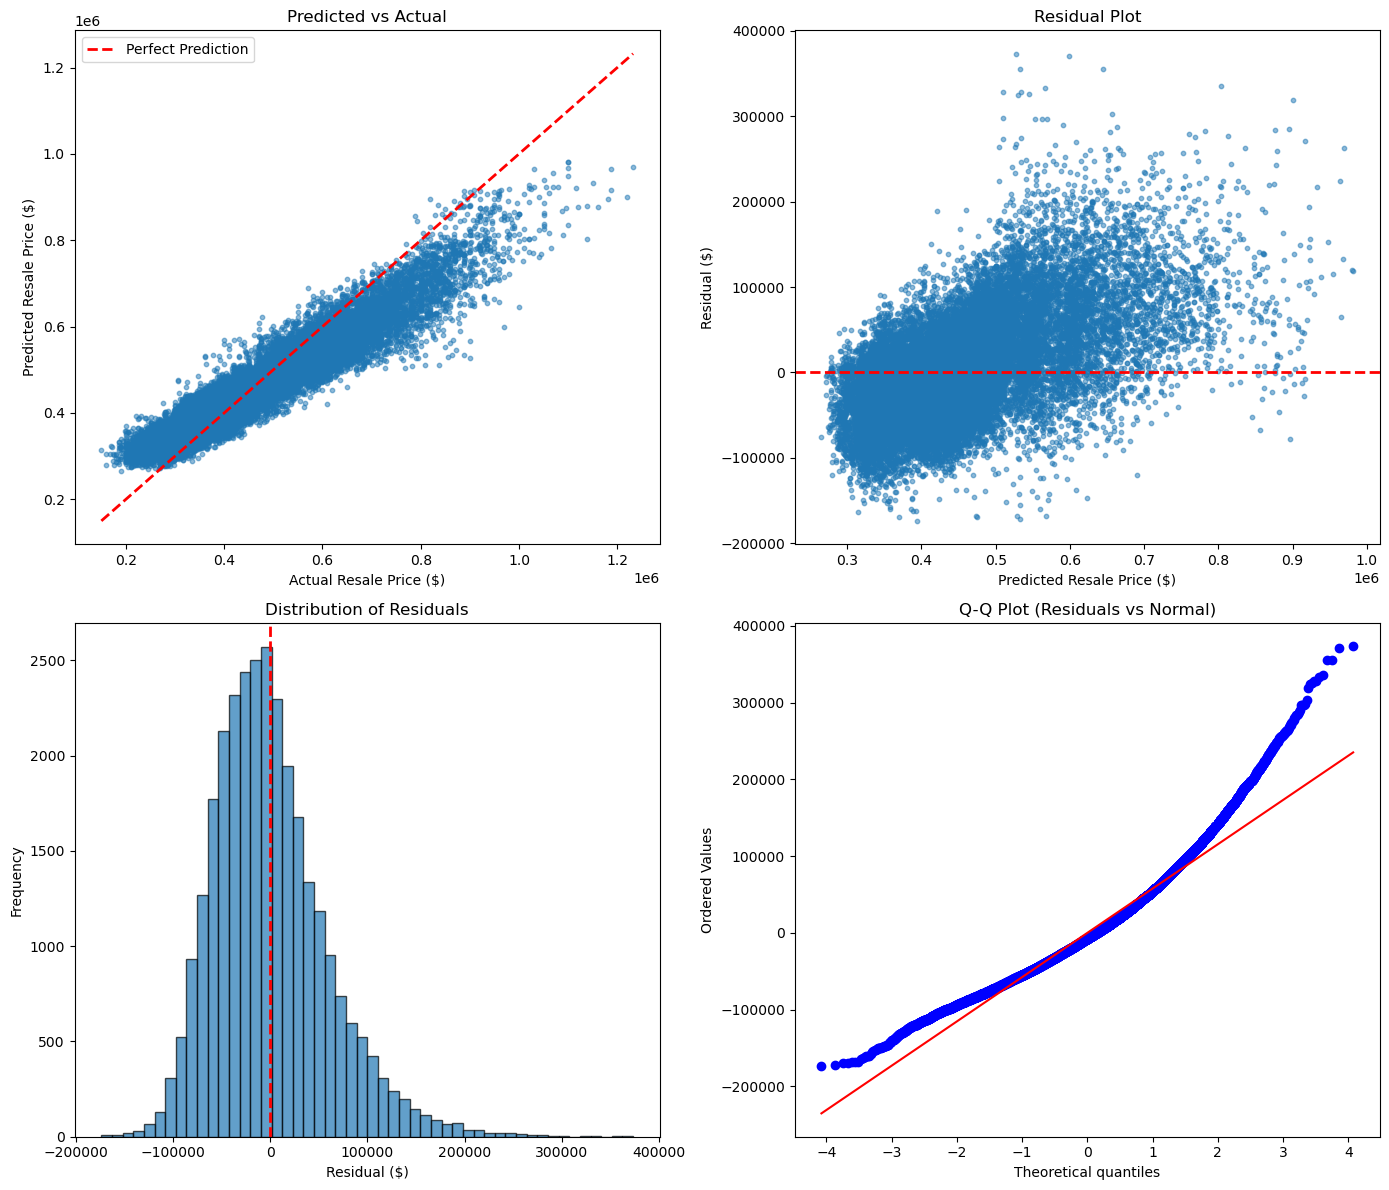

--- Curve Interpretation ---
1. Predicted vs Actual: Points should cluster around red line (perfect prediction)
2. Residual Plot: Points should be randomly scattered around 0 (no pattern)
3. Residual Histogram: Should be roughly symmetric/bell-shaped around 0
4. Q-Q Plot: Points should follow the straight line (indicates normal residuals)


In [13]:
# Model Performance Visualization Curves

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Predicted vs Actual Scatter Plot
ax1 = axes[0, 0]
ax1.scatter(comparison_df['Actual'], comparison_df['Predicted'], alpha=0.5, s=10)
min_val = min(comparison_df['Actual'].min(), comparison_df['Predicted'].min())
max_val = max(comparison_df['Actual'].max(), comparison_df['Predicted'].max())
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
ax1.set_xlabel('Actual Resale Price ($)')
ax1.set_ylabel('Predicted Resale Price ($)')
ax1.set_title('Predicted vs Actual')
ax1.legend()

# 2. Residual Plot (Residuals vs Predicted)
ax2 = axes[0, 1]
ax2.scatter(comparison_df['Predicted'], comparison_df['Residual'], alpha=0.5, s=10)
ax2.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax2.set_xlabel('Predicted Resale Price ($)')
ax2.set_ylabel('Residual ($)')
ax2.set_title('Residual Plot')

# 3. Residual Histogram
ax3 = axes[1, 0]
ax3.hist(comparison_df['Residual'], bins=50, edgecolor='black', alpha=0.7)
ax3.axvline(x=0, color='r', linestyle='--', linewidth=2)
ax3.set_xlabel('Residual ($)')
ax3.set_ylabel('Frequency')
ax3.set_title('Distribution of Residuals')

# 4. Q-Q Plot (check normality of residuals)
from scipy import stats
ax4 = axes[1, 1]
stats.probplot(comparison_df['Residual'], dist="norm", plot=ax4)
ax4.set_title('Q-Q Plot (Residuals vs Normal)')

plt.tight_layout()
plt.show()

# Summary interpretation
print("--- Curve Interpretation ---")
print("1. Predicted vs Actual: Points should cluster around red line (perfect prediction)")
print("2. Residual Plot: Points should be randomly scattered around 0 (no pattern)")
print("3. Residual Histogram: Should be roughly symmetric/bell-shaped around 0")
print("4. Q-Q Plot: Points should follow the straight line (indicates normal residuals)")

In [14]:
# Comprehensive Model Evaluation Metrics

from sklearn.metrics import r2_score, mean_absolute_percentage_error, explained_variance_score

# Calculate additional regression metrics
r2 = r2_score(y_valid, valid_predictions)
mape = mean_absolute_percentage_error(y_valid, valid_predictions) * 100
explained_var = explained_variance_score(y_valid, valid_predictions)

print("=" * 50)
print("COMPREHENSIVE EVALUATION METRICS")
print("=" * 50)
print(f"\n1. R² Score (Coefficient of Determination): {r2:.4f}")
print(f"   - Interpretation: {r2*100:.2f}% of price variance is explained by the model")
print(f"   - Range: 0 (no fit) to 1 (perfect fit)")

print(f"\n2. RMSE (Root Mean Squared Error): ${rmse:,.2f}")
print(f"   - Interpretation: Typical prediction error is ${rmse:,.0f}")

print(f"\n3. MAE (Mean Absolute Error): ${mae:,.2f}")
print(f"   - Interpretation: Average absolute difference between predicted and actual")

print(f"\n4. MAPE (Mean Absolute Percentage Error): {mape:.2f}%")
print(f"   - Interpretation: Average percentage error is {mape:.1f}%")

print(f"\n5. Explained Variance Score: {explained_var:.4f}")
print(f"   - Interpretation: {explained_var*100:.2f}% of variance captured")

print("\n" + "=" * 50)
print("METRIC SUMMARY TABLE")
print("=" * 50)

metrics_summary = pd.DataFrame({
    "Metric": ["R² Score", "RMSE ($)", "MAE ($)", "MAPE (%)", "Explained Variance"],
    "Value": [f"{r2:.4f}", f"{rmse:,.2f}", f"{mae:,.2f}", f"{mape:.2f}%", f"{explained_var:.4f}"],
    "Interpretation": [
        f"Explains {r2*100:.1f}% of variance",
        f"Typical error of ${rmse:,.0f}",
        f"Avg error of ${mae:,.0f}",
        f"{mape:.1f}% avg percentage error",
        f"Captures {explained_var*100:.1f}% of variance"
    ]
})

display(metrics_summary)

print("\n" + "=" * 50)
print("MODEL PERFORMANCE ASSESSMENT")
print("=" * 50)

if r2 >= 0.8:
    print("✓ R² Score: EXCELLENT (>0.8) - Model explains most price variance")
elif r2 >= 0.6:
    print("✓ R² Score: GOOD (0.6-0.8) - Model explains substantial variance")
elif r2 >= 0.4:
    print("△ R² Score: MODERATE (0.4-0.6) - Model explains some variance")
else:
    print("✗ R² Score: POOR (<0.4) - Model explains little variance")

if mape < 10:
    print("✓ MAPE: EXCELLENT (<10%) - Highly accurate predictions")
elif mape < 20:
    print("✓ MAPE: GOOD (10-20%) - Reasonably accurate predictions")
elif mape < 30:
    print("△ MAPE: MODERATE (20-30%) - Acceptable accuracy")
else:
    print("✗ MAPE: HIGH (>30%) - Significant prediction errors")

COMPREHENSIVE EVALUATION METRICS

1. R² Score (Coefficient of Determination): 0.8304
   - Interpretation: 83.04% of price variance is explained by the model
   - Range: 0 (no fit) to 1 (perfect fit)

2. RMSE (Root Mean Squared Error): $58,812.73
   - Interpretation: Typical prediction error is $58,813

3. MAE (Mean Absolute Error): $45,178.79
   - Interpretation: Average absolute difference between predicted and actual

4. MAPE (Mean Absolute Percentage Error): 10.75%
   - Interpretation: Average percentage error is 10.7%

5. Explained Variance Score: 0.8304
   - Interpretation: 83.04% of variance captured

METRIC SUMMARY TABLE


,Metric,Value,Interpretation
0,R² Score,0.8304,Explains 83.0% of variance
1,RMSE ($),"58,812.73","Typical error of $58,813"
2,MAE ($),"45,178.79","Avg error of $45,179"
3,MAPE (%),10.75%,10.7% avg percentage error
4,Explained Variance,0.8304,Captures 83.0% of variance



MODEL PERFORMANCE ASSESSMENT
✓ R² Score: EXCELLENT (>0.8) - Model explains most price variance
✓ MAPE: GOOD (10-20%) - Reasonably accurate predictions


TOP 20 MOST IMPORTANT FEATURES


,Feature,Importance
0,floor_area_sqm,0.059678
8,floor_area_sqft,0.053146
193,flat_type_3 ROOM,0.040701
10,max_floor_lvl,0.030954
15,3room_sold,0.025649
11,year_completed,0.023170
9,hdb_age,0.022538
196,flat_type_EXECUTIVE,0.022083
17,5room_sold,0.017619
1,lease_commence_date,0.017318


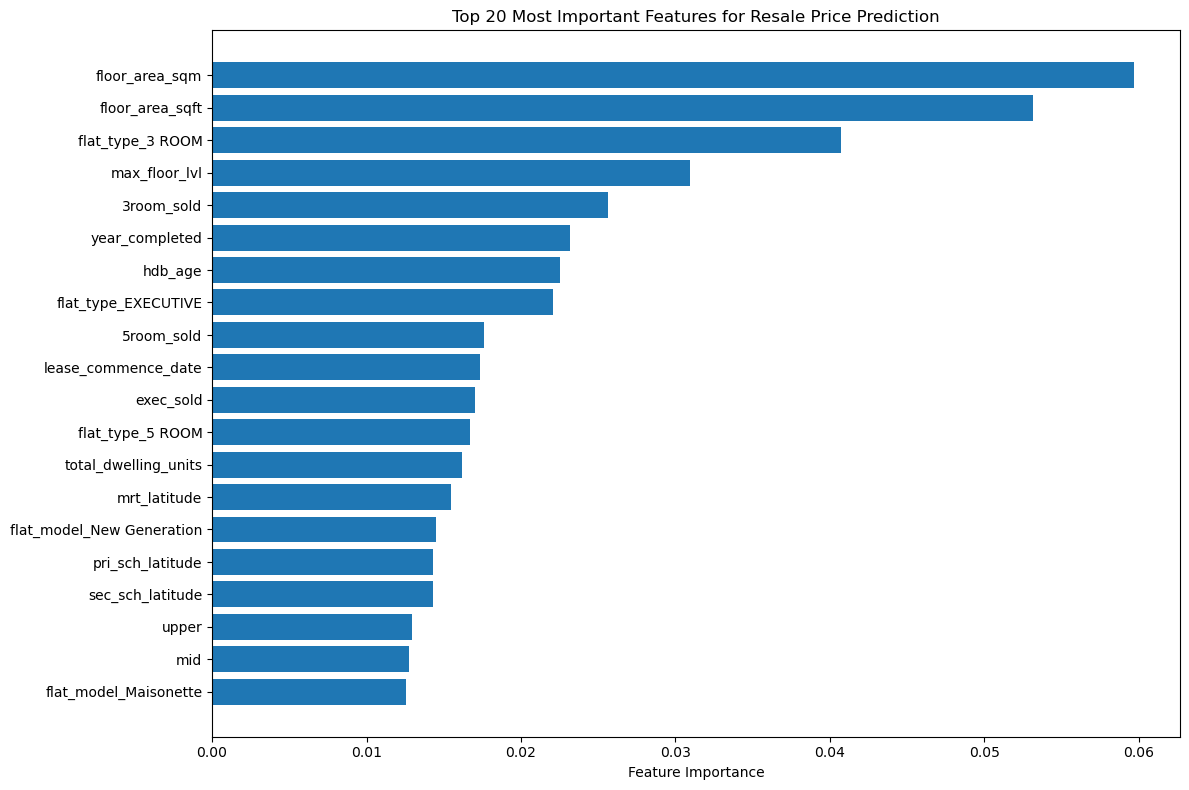


CUMULATIVE FEATURE IMPORTANCE
Top 10 features explain: 31.29% of variance
Top 20 features explain: 45.96% of variance
Top 50 features explain: 68.79% of variance

FEATURE IMPORTANCE BY CATEGORY


,Category,Total_Importance
0,Numeric Features,0.528148
1,Flat Type,0.172490
5,Other Categorical,0.167824
2,Flat Model,0.060606
4,Street Name,0.033274
3,Town (Location),0.024920
6,Storey Range,0.012738



FEATURE SELECTION RECOMMENDATIONS

1. HIGH-IMPACT FACTORS (keep all):
   - Floor area (sqm): Strongest predictor of price
   - Town/Location: Premium areas command higher prices
   - HDB age: Newer flats typically worth more
   - Flat type: 5-room, Executive, Multi-gen have different premiums

2. MEDIUM-IMPACT FACTORS (consider interactions):
   - Storey range: Higher floors may have different premiums by town
   - Flat model: Model A, Improved, Premium have different values
   - MRT distance: Accessibility affects price, especially in outer towns

3. LOW-IMPACT FACTORS (consider dropping):
   - 20 features with <0.1% importance each
   - Combined, these explain only 0.00% of variance

4. RECOMMENDED FEATURE ENGINEERING:
   a) Create 'town_flat_type' interaction (some towns favor certain types)
   b) Create 'size_category' from floor_area_sqm bins
   c) Target-encode high-cardinality features (town, street_name)
   d) Extract mid_storey from storey_range (already done: 'mid' column)



In [15]:
# Feature Importance Analysis and Feature Selection

# Extract feature names from preprocessor
# Get the one-hot encoded categorical feature names
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
cat_feature_names = cat_encoder.get_feature_names_out(categorical_features).tolist()
all_feature_names = numeric_features + cat_feature_names

# Get feature importances from the trained Random Forest model
rf_model = final_pipeline.named_steps['model']
feature_importances = rf_model.feature_importances_

# Create feature importance DataFrame
importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': feature_importances
}).sort_values('Importance', ascending=False)

print("=" * 60)
print("TOP 20 MOST IMPORTANT FEATURES")
print("=" * 60)
display(importance_df.head(20))

# Visualize top features
plt.figure(figsize=(12, 8))
top_20_features = importance_df.head(20)
plt.barh(range(len(top_20_features)), top_20_features['Importance'])
plt.yticks(range(len(top_20_features)), top_20_features['Feature'])
plt.xlabel('Feature Importance')
plt.title('Top 20 Most Important Features for Resale Price Prediction')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Calculate cumulative importance
cumulative_importance = importance_df['Importance'].cumsum()
print("\n" + "=" * 60)
print("CUMULATIVE FEATURE IMPORTANCE")
print("=" * 60)
print(f"Top 10 features explain: {cumulative_importance.iloc[9]:.2%} of variance")
print(f"Top 20 features explain: {cumulative_importance.iloc[19]:.2%} of variance")
print(f"Top 50 features explain: {cumulative_importance.iloc[49]:.2%} of variance")

# Group features by original category
print("\n" + "=" * 60)
print("FEATURE IMPORTANCE BY CATEGORY")
print("=" * 60)

category_importance = {}
for feature in importance_df['Feature']:
    importance_val = importance_df[importance_df['Feature'] == feature]['Importance'].values[0]
    
    # Determine category
    if feature in numeric_features:
        category = 'Numeric Features'
    elif 'town_' in feature:
        category = 'Town (Location)'
    elif 'flat_type_' in feature:
        category = 'Flat Type'
    elif 'flat_model_' in feature:
        category = 'Flat Model'
    elif 'storey_range_' in feature:
        category = 'Storey Range'
    elif 'street_name_' in feature:
        category = 'Street Name'
    else:
        category = 'Other Categorical'
    
    if category not in category_importance:
        category_importance[category] = 0
    category_importance[category] += importance_val

# Sort and display
category_df = pd.DataFrame(list(category_importance.items()), columns=['Category', 'Total_Importance'])
category_df = category_df.sort_values('Total_Importance', ascending=False)
display(category_df)

# Feature selection recommendations
print("\n" + "=" * 60)
print("FEATURE SELECTION RECOMMENDATIONS")
print("=" * 60)

print("\n1. HIGH-IMPACT FACTORS (keep all):")
print("   - Floor area (sqm): Strongest predictor of price")
print("   - Town/Location: Premium areas command higher prices")
print("   - HDB age: Newer flats typically worth more")
print("   - Flat type: 5-room, Executive, Multi-gen have different premiums")

print("\n2. MEDIUM-IMPACT FACTORS (consider interactions):")
print("   - Storey range: Higher floors may have different premiums by town")
print("   - Flat model: Model A, Improved, Premium have different values")
print("   - MRT distance: Accessibility affects price, especially in outer towns")

print("\n3. LOW-IMPACT FACTORS (consider dropping):")
low_importance_features = importance_df.tail(20)
print(f"   - {len(low_importance_features)} features with <0.1% importance each")
print(f"   - Combined, these explain only {low_importance_features['Importance'].sum():.2%} of variance")

print("\n4. RECOMMENDED FEATURE ENGINEERING:")
print("   a) Create 'town_flat_type' interaction (some towns favor certain types)")
print("   b) Create 'size_category' from floor_area_sqm bins")
print("   c) Target-encode high-cardinality features (town, street_name)")
print("   d) Extract mid_storey from storey_range (already done: 'mid' column)")

# Suggest features to drop (bottom 10%)
threshold = importance_df['Importance'].quantile(0.1)
features_to_drop = importance_df[importance_df['Importance'] < threshold]['Feature'].tolist()

print(f"\n5. CANDIDATES FOR REMOVAL ({len(features_to_drop)} features with <{threshold:.4f} importance):")
for feat in features_to_drop[:10]:
    print(f"   - {feat}")
if len(features_to_drop) > 10:
    print(f"   - ... and {len(features_to_drop) - 10} more")